In [2]:
from pathlib import Path
import pandas as pd
import re


path = Path(r"C:\Users\20241114\PycharmProjects\PythonProject\Data\c5e365714b6c98084c564fd69b91ccde80ae9133\2023-06\2023-06-avon-and-somerset-street.csv")

data = pd.read_csv(path)

data.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,220dca0aae67f3ffabe64c6bba30780a7d83a2f0feffab...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.510372,51.423406,On or near Durley Lane,E01014399,Bath and North East Somerset 001A,Other theft,Status update unavailable,NaN
1,a361588a61dfde21515f1324acc34f68196e2eeca99b83...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.512071,51.409470,On or near Harlech Close,E01014399,Bath and North East Somerset 001A,Other theft,Status update unavailable,NaN
2,b53ca2588e0d739bdbf249aa5c37ac5ced20a902d75c04...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.510372,51.423406,On or near Durley Lane,E01014399,Bath and North East Somerset 001A,Public order,Unable to prosecute suspect,NaN
3,6148d4757850c7cd1e0b548001585b3928582f036ca6a3...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.508867,51.416147,On or near St Francis Road,E01014399,Bath and North East Somerset 001A,Vehicle crime,Status update unavailable,NaN
4,cc4ba2b9ae13a8f1910cc5c138e760079e7cb8d0969615...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.510372,51.423406,On or near Durley Lane,E01014399,Bath and North East Somerset 001A,Vehicle crime,Status update unavailable,NaN


In [2]:
unique_crimes = data['Crime type'].unique()
print(unique_crimes)
unique_lsoas = data['LSOA code'].unique()
print(unique_lsoas)

<StringArray>
[                 'Other theft',                 'Public order',
                'Vehicle crime', 'Violence and sexual offences',
        'Anti-social behaviour',                     'Burglary',
    'Criminal damage and arson',                        'Drugs',
                  'Shoplifting',                  'Other crime',
                      'Robbery',                'Bicycle theft',
        'Possession of weapons',        'Theft from the person']
Length: 14, dtype: str
<StringArray>
['E01014399', 'E01014400', 'E01014401', 'E01014403', 'E01014404', 'E01035205',
 'E01035206', 'E01014395', 'E01014396', 'E01014397',
 ...
 'E01029230', 'E01004014', 'E01022353', 'E01022381', 'E01020223', 'E01022451',
 'E01012529', 'E01032060', 'E01032121',         nan]
Length: 1047, dtype: str


In [3]:
path2 = Path(r"C:\Users\20241114\PycharmProjects\PythonProject\Data\c5e365714b6c98084c564fd69b91ccde80ae9133\2023-06\2023-06-avon-and-somerset-stop-and-search.csv")

data2 = pd.read_csv(path2)
data2.head()


,Type,Date,Part of a policing operation,Policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome linked to object of search,Removal of more than just outer clothing
0,Person search,2023-06-01T01:26:32+00:00,NaN,NaN,NaN,NaN,Male,25-34,White - English/Welsh/Scottish/Northern Irish/...,White,Police and Criminal Evidence Act 1984 (section 1),Offensive weapons,A no further action disposal,NaN,False
1,Person search,2023-06-01T06:22:21+00:00,NaN,NaN,51.380991,-2.363740,Male,25-34,Other ethnic group - Not stated,Black,Police and Criminal Evidence Act 1984 (section 1),Article for use in theft,Arrest,True,False
2,Person search,2023-06-01T10:34:36+00:00,NaN,NaN,51.412247,-2.599539,Male,over 34,Other ethnic group - Not stated,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False
3,Person search,2023-06-01T14:11:59+00:00,NaN,NaN,51.347890,-2.965923,Male,25-34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False
4,Person search,2023-06-01T15:25:49+00:00,NaN,NaN,51.449331,-2.588470,Female,over 34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False


In [4]:
path3 = Path(r"C:\Users\20241114\PycharmProjects\PythonProject\Data\c5e365714b6c98084c564fd69b91ccde80ae9133\2023-06\2023-06-avon-and-somerset-outcomes.csv")
data3 = pd.read_csv(path3)
data3.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Outcome type
0,5a949f534a9cfe06441ff3ffe79f6819818d1a4b371bc5...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Suspect charged
1,641c29075ff8ba90ff96d664091a6165c1b9ea4d9c4e87...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Offender given a caution
2,6a6e76b8af76b0320987134d203174ec6de4732ef4e990...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Formal action is not in the public interest
3,80b1ad0d45c956c5d2e96a8e0603b8f6d97900a156ae37...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect
4,967783bb121f786fbd479130ab07a549baeae0534a7046...,2023-06,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Local resolution


In [5]:
#Loading external datafiles and storing them in dataframes.
df_weights = pd.read_excel(r'C:\Users\20241114\PycharmProjects\PythonProject\Data\datatool.xls', sheet_name= 'List of weights', skiprows= 6)
df_offence_list = pd.read_excel(r'C:\Users\20241114\PycharmProjects\PythonProject\Data\notifiable-offence-and-notifiable-reported-incidents-april-2026.ods', skiprows= 1)


def match_code(code):
    """Extracts first digits of given code and returns the first appearing integer value as a string."""
    match = re.search(r'\d+', str(code))
    if match:
        return str(int(match.group()))
    else:
        return None

#Creating a new column to extract and store the formatted first integer value in both dataframes.
df_weights['bridge_code'] = df_weights['Offence code'].apply(match_code)
df_offence_list['bridge_code'] = df_offence_list['Home Office code'].apply(match_code)

#Extracting unique integer values and creating key value pair where the integer value is the key and the higher level type of crime is the value.
class_dict = df_offence_list.drop_duplicates(subset= ['bridge_code']).set_index('bridge_code')['Class'].to_dict()
#Creating a new column which will store the mapped higher level crime types based on the unique integer value belonging to the higher level crime type.
df_weights['class'] = df_weights['bridge_code'].map(class_dict)
# Dropping any row in the weights dataframe where the Offence code column does not contain a code.
df_weights = df_weights.dropna(subset=['Offence code']).copy()
#Ensuring that spaces or capital letters will not cause issues while mapping.
df_weights['class'] = df_weights['class'].str.strip().str.title()
#Dropping rows with NaN values.
df_weights = df_weights.dropna(subset=['class']).copy()
# Resetting the index so that the row numbers start at 0 again.
df_weights = df_weights.reset_index(drop=True)

#Extracting unique integer values and creating key value pair where the integer value is the key and the lower level type of crime is the value.
subclass_dict = df_offence_list.drop_duplicates(subset= ['bridge_code']).set_index('bridge_code')['Sub class'].to_dict()
#Creating a new column which will store the mapped lower level crime types based on the unique integer value belonging to the lower level crime type.
df_weights['sub_class'] = df_weights['bridge_code'].map(subclass_dict)
#Ensuring that spaces or capital letters will not cause issues while mapping.
df_weights['sub_class'] = df_weights['sub_class'].str.strip().str.title()
#Filling empty subclasses with the value unknown so they don't show up as NaN.
df_weights['sub_class'] = df_weights['sub_class'].fillna('Unknown')

#Creating a mapping dictionary to map higher level type of crimes to crime categories in the crime dataset. NOTE: All crimes considered as theft are mapped to other theft in this higher level crime mapping. Theft categories contained in the notifiable-offence-and-notifiable-reported-incidents-april-2026.ops file as well as in the crime dataset will get their own appropriate mapping in the lower level mapping.
hl_crime_mapping_dict = {
    'Violence Against The Person': 'Violence and sexual offences',
    'Sexual Offences': 'Violence and sexual offences',
    'Burglary': 'Burglary',
    'Robbery': 'Robbery',
    'Vehicle Offences': 'Vehicle crime',
    'Theft': 'Other theft',
    'Arson And Criminal Damage': 'Criminal damage and arson',
    'Drug Offences': 'Drugs',
    'Possession Of Weapons': 'Possession of weapons',
    'Public Order Offences': 'Public order',
    'Miscellaneous Crimes Against Society': 'Other crime',
    'Nfib Fraud': 'Other crime'
}

#Mapping the higher level crime categories to the new created column crime_category.
df_weights['crime_category'] = df_weights['class'].map(hl_crime_mapping_dict)

#Creating a dictionary to map lower level type of crimes, specifically for thefts.
ll_crime_mapping_dict = {
    'Shoplifting': 'Shoplifting',
    'Bicycle Theft': 'Bicycle theft',
    'Theft From The Person': 'Theft from the person'
}

def refine_categories(row):
    """Prioritizes lower level crime types, specifically for thefts when there are subclasses available."""
    if row['sub_class'] in ll_crime_mapping_dict:
        return ll_crime_mapping_dict[row['sub_class']]
    return row['crime_category']

#Giving thefts which have a specific category in the crime dataset their category.
df_weights['crime_category'] = df_weights.apply(refine_categories, axis=1)

#Calculating the median per crime category.
category_weights = df_weights.groupby('crime_category')['Weight'].median().reset_index()
#Creating a dictionary to map the weights of each specific crime category correctly.
crime_weights_dict = category_weights.set_index('crime_category')['Weight'].to_dict()

#Crime categories.
crime_categories = [
    'Violence and sexual offences', 'Burglary', 'Robbery', 'Vehicle crime',
    'Criminal damage and arson', 'Drugs', 'Possession of weapons',
    'Public order', 'Other crime', 'Shoplifting', 'Bicycle theft',
    'Theft from the person', 'Other theft', 'Anti-social behaviour'
]

#Creating a dataframe to display the weights per crime category.
df_crime_weights = pd.DataFrame({
    'Crime Type': crime_categories,
    'Weight': [crime_weights_dict.get(cat, 0.0) for cat in crime_categories]
})

#Ensuring Anti-social behaviour has weight of exactly 1.
df_crime_weights.loc[df_crime_weights['Crime Type'] == 'Anti-social behaviour', 'Weight'] = 1

print(df_crime_weights)

                      Crime Type       Weight
0   Violence and sexual offences  1058.555858
1                       Burglary   564.016259
2                        Robbery   993.551571
3                  Vehicle crime    34.603172
4      Criminal damage and arson     9.163133
5                          Drugs   666.677995
6          Possession of weapons  1710.723625
7                   Public order    69.290900
8                    Other crime   185.807900
9                    Shoplifting    13.086039
10                 Bicycle theft    18.550268
11         Theft from the person    87.011103
12                   Other theft    42.575167
13         Anti-social behaviour     1.000000


In [6]:
df_offence_list['Class'].unique()

<StringArray>
[         'Violence Against The Person',
                'Possession of weapons',
                'Public Order Offences',
 'Miscellaneous Crimes Against Society',
                      'Sexual Offences',
                             'Burglary',
                              'Robbery',
                                'Theft',
                     'Vehicle offences',
                           'NFIB Fraud',
 'Miscellaneous crimes against society',
            'Arson and Criminal Damage',
                        'Drug Offences',
                'Public Order offences',
                              'Theft  ']
Length: 15, dtype: str

In [7]:
df_offence_list['Sub class'].unique()

<StringArray>
[                                         'Homicide',
                             'Violence with injury ',
                           'Violence without injury',
                           'violence without injury',
 'Death or serious injury caused by illegal driving',
                           'Stalking and Harassment',
                             'Violence with Injury ',
                              'Violence with Injury',
                                                 nan,
                                                 ' ',
                             'Other sexual offences',
                                              'Rape',
                    'Residential Burglary of a Home',
      'Residential Burglary of Unconnected Building',
                   'Burglary Business and Community',
                                       'Other theft',
                            'Theft from the person ',
                                     'Bicycle theft',
              

In [8]:
import pandas as pd
import gc
from pathlib import Path

#Creating path where all crime folders are at.
data_path = Path(r'C:\Users\20241114\PycharmProjects\PythonProject\Data\c5e365714b6c98084c564fd69b91ccde80ae9133')
#Defining the relevant years to analyze.
target_years = ['2023', '2024', '2025', '2026']
lsoa_intensity_scores_dict = {}
crime_type_harm_dict = {}

#Defining all relevant files.
all_files = list(data_path.glob('**/*-street.csv'))

#Finding all relevant files in the target years.
files_to_load = []
for file in all_files:
    for year in target_years:
        if year in str(file):
            files_to_load.append(file)
            break

print(f'There are {len(files_to_load)} monthly files to analyze')

#Looping through each relevant file to:
# - map each crime type to its corresponding weight
# - calculate for each crime type the harm it causes across the entire UK by aggregating the weight by crime type.
# - aggregate by LSOA and crime type, and calculate the weighted sum of each month for each LSOA.
# - sum the monthly sums of each LSOA so that in the end the total crime intensity index score is calculated per LSOA over 3 years.
for i, file in enumerate(files_to_load):
    try:
        df_temp = pd.read_csv(file, usecols=['LSOA code', 'Crime type'])
        df_temp = df_temp.dropna(subset=['LSOA code'])
        df_temp['weight'] = df_temp['Crime type'].map(crime_weights_dict).fillna(1.0)

        monthly_sum = df_temp.groupby(['LSOA code', 'Crime type'])['weight'].sum()
        monthly_crime_harm = df_temp.groupby('Crime type')['weight'].sum()

        for crime, harm in monthly_crime_harm.items():
            crime_type_harm_dict[crime] = crime_type_harm_dict.get(crime, 0) + harm

        for (lsoa, crime), total in monthly_sum.items():
            lsoa_intensity_scores_dict[(lsoa, crime)] = lsoa_intensity_scores_dict.get((lsoa, crime), 0) + total

        del df_temp
        gc.collect()

        if (i + 1) % 12 == 0:
            print(f'Processed {i + 1} files')

    except Exception as e:
        print(f'File {file.name} could not be processed due to: {e}')

#Converting dictionary to a dataframe so that we can analyze the top 5 most severe and impactful crime types in the UK.
df_national_harm = pd.DataFrame(list(crime_type_harm_dict.items()), columns=['Crime_Type', 'Total_Harm_Score'])
#Sorting from worst to least harmful crime types.
df_national_harm = df_national_harm.sort_values(by='Total_Harm_Score', ascending=False).reset_index(drop=True)
#Calculating the total harm scores per crime type.
total_nationwide_harm = df_national_harm['Total_Harm_Score'].sum()
#Calculating the ratio of the total harm score of the entire UK per crime type.
df_national_harm['Percentage_of_Total'] = (df_national_harm['Total_Harm_Score'] / total_nationwide_harm) * 100
#Calculating the cumulative percentage starting from the crime type with the highest score.
df_national_harm['Cumulative_Percentage'] = df_national_harm['Percentage_of_Total'].cumsum()

print("National Crime Harm Distribution")
print(df_national_harm.round(2))

#Getting the top 5 most severe and impactful crime types within the entire UK.
top_5_crimes = df_national_harm.head(5)['Crime_Type'].tolist()

#Summing up all crime intensity index scores for the most severe crime types across the entire UK per LSOA.
final_lsoa_totals = {}
for (lsoa, crime), harm in lsoa_intensity_scores_dict.items():
    if crime in top_5_crimes:
        final_lsoa_totals[lsoa] = final_lsoa_totals.get(lsoa, 0) + harm

#Creating a dataframe from the intensity dictionary to display the crime intensity index per LSOA in a proper way.
df_cii = pd.DataFrame(list(final_lsoa_totals.items()), columns=['LSOA code', 'CII_Total'])
df_cii['Annual_CII'] = df_cii['CII_Total'] / 3

print(df_cii.head())

There are 1563 monthly files to analyze
Processed 12 files
Processed 24 files
Processed 36 files
Processed 48 files
Processed 60 files
Processed 72 files
Processed 84 files
Processed 96 files
Processed 108 files
Processed 120 files
Processed 132 files
Processed 144 files
Processed 156 files
Processed 168 files
Processed 180 files
Processed 192 files
Processed 204 files
Processed 216 files
Processed 228 files
Processed 240 files
Processed 252 files
Processed 264 files
Processed 276 files
Processed 288 files
Processed 300 files
Processed 312 files
Processed 324 files
Processed 336 files
Processed 348 files
Processed 360 files
Processed 372 files
Processed 384 files
Processed 396 files
Processed 408 files
Processed 420 files
Processed 432 files
Processed 444 files
Processed 456 files
Processed 468 files
Processed 480 files
Processed 492 files
Processed 504 files
Processed 516 files
Processed 528 files
Processed 540 files
Processed 552 files
Processed 564 files
Processed 576 files
Processe

C:\Users\20241114\AppData\Local\Temp\ipykernel_22472\1109411259.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


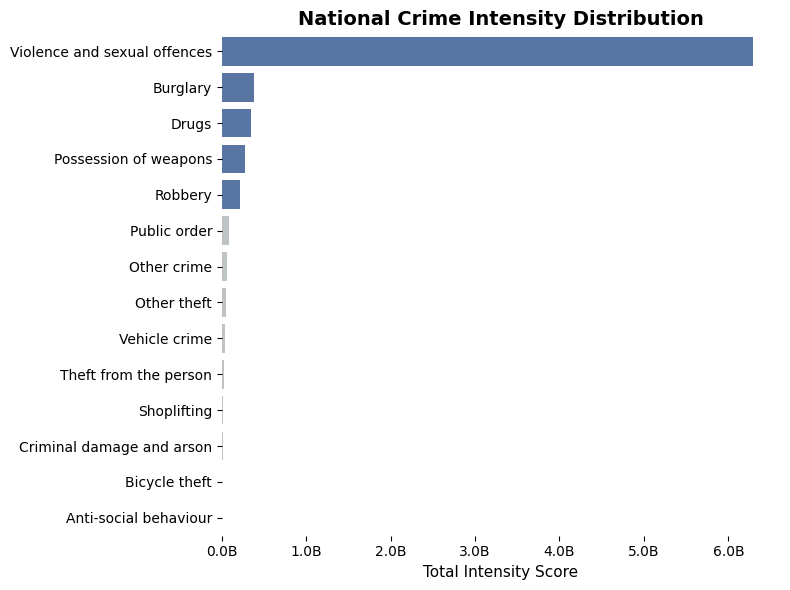

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4c72b0' if i < 5 else '#bdc3c7' for i in range(len(df_national_harm))]

sns.barplot(
    x='Total_Harm_Score',
    y='Crime_Type',
    data=df_national_harm,
    palette=colors,
    ax=ax
)

ax.set_title('National Crime Intensity Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Intensity Score', fontsize=11)
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

sns.despine(left=True, bottom=True, top=True, right=True)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))

plt.tight_layout()
plt.savefig('horizontal_briefing_plot.png', dpi=300, bbox_inches='tight')
plt.show()


In [35]:

top_5 = df_national_harm.head(5).copy()
others_harm = df_national_harm.iloc[5:]['Total_Harm_Score'].sum()
others_perc = df_national_harm.iloc[5:]['Percentage_of_Total'].sum()

others_row = pd.DataFrame({
    'Crime_Type': ['All Other Categories'],
    'Total_Harm_Score': [others_harm],
    'Percentage_of_Total': [others_perc],
    'Cumulative_Percentage': [100.0]
})

strategic_table = pd.concat([top_5, others_row], ignore_index=True)

strategic_table['Total_Harm_Score'] = strategic_table['Total_Harm_Score'].apply(lambda x: f"{x:,.0f}")
strategic_table['Percentage_of_Total'] = strategic_table['Percentage_of_Total'].apply(lambda x: f"{x:.1f}%")
strategic_table['Cumulative_Percentage'] = strategic_table['Cumulative_Percentage'].apply(lambda x: f"{x:.1f}%")

strategic_table.columns = ['Crime Category', 'Harm Score (CII)', 'Impact (%)', 'Cumulative Total (%)']

print("Strategic Justification Table (Top 5 Focus)")
print(strategic_table)

Strategic Justification Table (Top 5 Focus)
                 Crime Category Harm Score (CII) Impact (%)  \
0  Violence and sexual offences    6,297,421,842      80.5%   
1                      Burglary      383,776,967       4.9%   
2                         Drugs      351,257,302       4.5%   
3         Possession of weapons      270,790,443       3.5%   
4                       Robbery      220,029,944       2.8%   
5          All Other Categories      301,969,696       3.9%   

  Cumulative Total (%)  
0                80.5%  
1                85.4%  
2                89.9%  
3                93.3%  
4                96.1%  
5               100.0%  


In [1]:
import pandas as pd
import geopandas as gpd

df_predictions = pd.read_csv(r"C:\Users\20241114\PycharmProjects\PythonProject\Prophet Forecasting\Validation March\march_2026_forecast.csv")
map_path = r"C:\Users\20241114\PycharmProjects\PythonProject\Data\Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BFC_V10_-7599572456947714539\LSOA_2021_EW_BFC_V10.shp"
gdf_map = gpd.read_file(map_path)

df_predictions = df_predictions[df_predictions['LSOA_ID'].str.startswith('E')]
gdf_map = gdf_map.rename(columns={'LSOA21CD': 'LSOA_ID'})
gdf_map_england = gdf_map[gdf_map['LSOA_ID'].str.startswith('E')]

exploration_merge = gdf_map_england.merge(df_predictions, on='LSOA_ID', how='left')

total_missing = exploration_merge['yhat'].isna().sum()
total_lsoas = len(gdf_map_england)

print(f"Total English LSOAs in shapefile: {total_lsoas}")
print(f"Total missing Prophet predictions: {total_missing}")
print(f"Failure Rate: {(total_missing / total_lsoas) * 100:.2f}%")

Total English LSOAs in shapefile: 33755
Total missing Prophet predictions: 1026
Failure Rate: 3.04%


In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

#Load the dataset
imd_path = r'C:\Users\20241114\PycharmProjects\PythonProject\Data\File_7_IoD2025_All_Ranks_Scores_Deciles_Population_Denominators.csv'

#Choosing columns to analyze.
relevant_columns = [
    'LSOA code (2021)',
    'LSOA name (2021)',
    'Index of Multiple Deprivation (IMD) Score',
    'Income Score (rate)'
]

df_imd = pd.read_csv(imd_path, usecols= relevant_columns)

#Giving columns a clear name.
df_imd.columns = ['LSOA code', 'LSOA_Name_2021', 'IMD_Score', 'Income_Rate']

#Merging the crime intensity index dataframe with the imd dataframe safely so that no rows are being discarded.
df_final = pd.merge(df_cii, df_imd, on='LSOA code', how='left')
#Filling the rows without a LSOA name in the imd dataset with placeholders as the imd dataset only contains the LSOA names of England.
df_final['LSOA_Name_2021'] = df_final['LSOA_Name_2021'].fillna('Unknown / Outside England')
df_final

,LSOA code,CII_Total,Annual_CII,LSOA_Name_2021,IMD_Score,Income_Rate
0,E01004176,1.356249e+05,45208.308525,Sutton 010E,14.843,0.180
1,E01004331,1.452588e+05,48419.596552,Waltham Forest 028E,30.697,0.386
2,E01014370,1.612968e+06,537655.876498,Bath and North East Somerset 007A,27.580,0.238
3,E01014371,1.246722e+06,415574.146187,Bath and North East Somerset 007B,19.876,0.095
4,E01014372,5.011031e+05,167034.351757,Bath and North East Somerset 007C,17.590,0.120
...,...,...,...,...,...,...
35599,E01006184,1.058556e+03,352.851953,Trafford 008D,24.718,0.239
35600,E01033679,1.058556e+03,352.851953,Manchester 009G,72.094,0.588
35601,E01004969,1.058556e+03,352.851953,Bury 022A,38.867,0.282
35602,E01005280,1.058556e+03,352.851953,Manchester 026A,45.333,0.567


       Scaled_CII  Scaled_Income
count   32729.000      32729.000
mean        0.000         -0.000
std         1.000          1.000
min        -5.569         -1.455
25%        -0.456         -0.787
50%         0.056         -0.285
75%         0.578          0.590
max         3.990          4.950


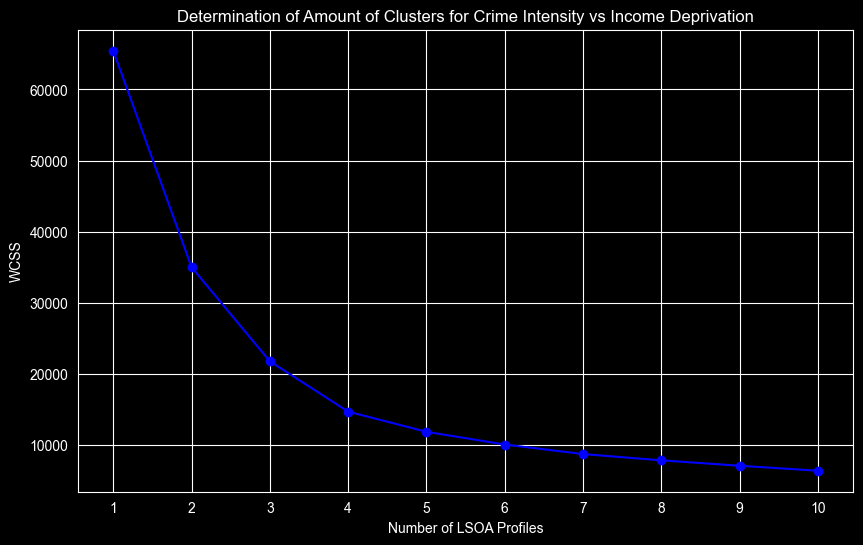

In [10]:
#Preparing data to be able to perform k-means clustering.
#Log transforming the crime intensity index scores so that LSOAs with outlier values will not affect the k-means clustering.
df_final['Log_CII'] = np.log1p(df_final['Annual_CII'])


#Dropping rows with missing income rate or crime intensity index score.
df_model_input = df_final.dropna(subset=['Income_Rate', 'Log_CII']).copy()

#Standardizing relevant columns to make sure that in both dimensions we have normalized z-scores to be able to perform k-means clustering.
scaler = StandardScaler()
features_to_scale = ['Log_CII', 'Income_Rate']
df_model_input[['Scaled_CII', 'Scaled_Income']] = scaler.fit_transform(df_model_input[features_to_scale])

#Verifying whether both dimensions are now standardized to z-score values.
verification = round(df_model_input[['Scaled_CII', 'Scaled_Income']].describe(), 3)
print(verification)


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Extracting the standardized values of each LSOA.
relevant_data = df_model_input[['Scaled_CII', 'Scaled_Income']].values

#Creating the list wcss to store the within cluster sum of squares which measures the distance within each cluster to the centroid.
wcss = []
max_clusters = 10 # Testing between 1 and 10 possible groups

#Running k-means clustering algorithm for every k from 1 to 10 to find optimal amount of clusters. The ideal k is the number of clusters for which the wcss still dropped significantly compared to the previous k number of clusters (Elbow Method).
for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(relevant_data)
    wcss.append(kmeans.inertia_)

#Plotting the graph to determine optimal number of clusters.
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='-', color='b')
plt.title('Determination of Amount of Clusters for Crime Intensity vs Income Deprivation')
plt.xlabel('Number of LSOA Profiles')
plt.ylabel('WCSS')
plt.xticks(range(1, max_clusters + 1))
plt.grid(True, linestyle='-')
plt.show()

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

#Performing k-means clustering with k = 4.
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
df_model_input['Cluster'] = kmeans.fit_predict(relevant_data)

#Computing the statistics of the centroid LSOA of each cluster.
centroid_data = df_model_input.groupby('Cluster').agg({
    'Annual_CII': 'mean',
    'Income_Rate': 'mean',
    'LSOA code': 'count'
}).rename(columns={'LSOA code': 'LSOA_Count'})

print("Centroid Data of Different English LSOA Profiles")
print(centroid_data.sort_values(by='Annual_CII'))

Centroid Data of Different English LSOA Profiles
            Annual_CII  Income_Rate  LSOA_Count
Cluster                                        
1           598.989211     0.322695         679
3         31828.907479     0.104598       13999
0         88927.956974     0.236159       11784
2        139057.407327     0.479762        6267


In [12]:
#Creating a mapping dictionary providing names to clusters based on annual CII and income rate.
mapping_dict = {
    0: "Very Low Intensity - Moderate Deprivation",
    1: "High Intensity - High Deprivation",
    2: "Low Intensity - Low Deprivation",
    3: "Moderate Intensity - Moderate Deprivation"
}

df_model_input['LSOA_Profile_Name'] = df_model_input['Cluster'].map(mapping_dict)

#Computing the statistics of the centroid LSOA of each cluster.
centroid_data = df_model_input.groupby('LSOA_Profile_Name').agg({
    'Annual_CII': 'mean',
    'Income_Rate': 'mean',
    'LSOA code': 'count'
}).rename(columns={'LSOA code': 'LSOA_Count'}).sort_values(by='Annual_CII')

#Displaying data of centroid LSOAs rounded off by 3 decimals.
print("Centroid Data of Different LSOA Profiles")
print(centroid_data.round(3))

Centroid Data of Different LSOA Profiles
                                           Annual_CII  Income_Rate  LSOA_Count
LSOA_Profile_Name                                                             
High Intensity - High Deprivation             598.989        0.323         679
Moderate Intensity - Moderate Deprivation   31828.907        0.105       13999
Very Low Intensity - Moderate Deprivation   88927.957        0.236       11784
Low Intensity - Low Deprivation            139057.407        0.480        6267


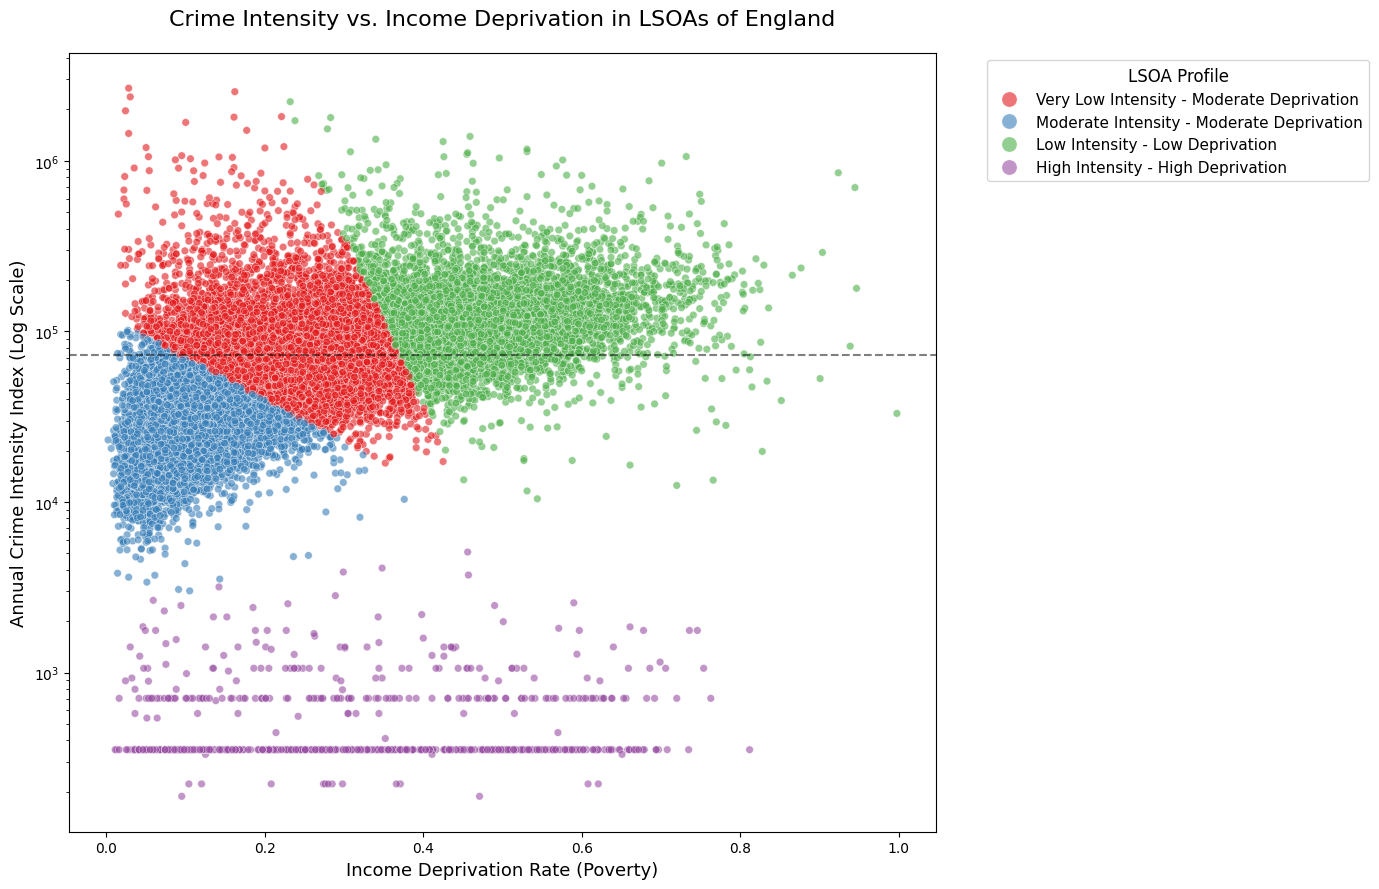

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

#Plotting k-means clusters.
#Alpha is set to 0.6 so that it is visible where the dots overlap.
plt.figure(figsize=(14, 9))
scatter = sns.scatterplot(
    data=df_model_input,
    x='Income_Rate',
    y='Annual_CII',
    hue='LSOA_Profile_Name',
    palette= 'Set1',
    alpha=0.6,
    s= 30
)
#Assuring that the crime intensity index is log scaled.
plt.yscale('log')
plt.title('Crime Intensity vs. Income Deprivation in LSOAs of England', fontsize=16, pad=20)
plt.xlabel('Income Deprivation Rate (Poverty)', fontsize=13)
plt.ylabel('Annual Crime Intensity Index (Log Scale)', fontsize=13)
legend = plt.legend(
    title='LSOA Profile',
    bbox_to_anchor= (1.05, 1),
    loc= 'upper left',
    fontsize= 11,
    title_fontsize= 12,
    markerscale= 2.0,
)
#Highlighting the LSOA having the national average crime intensity index score.
plt.axhline(df_model_input['Annual_CII'].mean(), color='black', linestyle='--', alpha=0.5, label='National Avg CII')
plt.tight_layout()
plt.show()

In [14]:
df_model_input

,LSOA code,CII_Total,Annual_CII,LSOA_Name_2021,IMD_Score,Income_Rate,LSOA_Name_2011,Log_CII,Scaled_CII,Scaled_Income,Cluster,LSOA_Profile_Name
0,E01004176,1.356249e+05,45208.308525,Sutton 010E,14.843,0.180,Sutton 010E,10.719058,-0.088995,-0.310793,0,Very Low Intensity - Moderate Deprivation
1,E01004331,1.452588e+05,48419.596552,Waltham Forest 028E,30.697,0.386,Waltham Forest 028E,10.787681,-0.020335,1.013980,0,Very Low Intensity - Moderate Deprivation
2,E01014370,1.612968e+06,537655.876498,Bath and North East Somerset 007A,27.580,0.238,Bath and North East Somerset 007A,13.194976,2.388308,0.062201,0,Very Low Intensity - Moderate Deprivation
3,E01014371,1.246722e+06,415574.146187,Bath and North East Somerset 007B,19.876,0.095,Bath and North East Somerset 007B,12.937419,2.130607,-0.857422,0,Very Low Intensity - Moderate Deprivation
4,E01014372,5.011031e+05,167034.351757,Bath and North East Somerset 007C,17.590,0.120,Bath and North East Somerset 007C,12.025961,1.218639,-0.696649,0,Very Low Intensity - Moderate Deprivation
...,...,...,...,...,...,...,...,...,...,...,...,...
35599,E01006184,1.058556e+03,352.851953,Trafford 008D,24.718,0.239,Trafford 008D,5.868879,-4.941890,0.068632,1,High Intensity - High Deprivation
35600,E01033679,1.058556e+03,352.851953,Manchester 009G,72.094,0.588,Manchester 009G,5.868879,-4.941890,2.313028,1,High Intensity - High Deprivation
35601,E01004969,1.058556e+03,352.851953,Bury 022A,38.867,0.282,Bury 022A,5.868879,-4.941890,0.345162,1,High Intensity - High Deprivation
35602,E01005280,1.058556e+03,352.851953,Manchester 026A,45.333,0.567,Manchester 026A,5.868879,-4.941890,2.177979,1,High Intensity - High Deprivation


In [15]:
df_crime_weights

,Crime Type,Weight
0,Violence and sexual offences,1058.555858
1,Burglary,564.016259
2,Robbery,993.551571
3,Vehicle crime,34.603172
4,Criminal damage and arson,9.163133
5,Drugs,666.677995
6,Possession of weapons,1710.723625
7,Public order,69.290900
8,Other crime,185.807900
9,Shoplifting,13.086039


In [16]:
path4 = Path(r"C:\Users\20241114\PycharmProjects\PythonProject\Prophet Forecasting\Validation March\march_2026_forecast.csv")

data4= pd.read_csv(path4)
data4.head()

,ds,yhat,yhat_lower,yhat_upper,LSOA_ID
0,2026-03-01,4472.821757,1768.332774,7050.467863,E01028559
1,2026-03-01,10941.137667,7562.751882,14450.365219,E01013649
2,2026-03-01,16034.440081,12605.622860,19448.577687,E01013212
3,2026-03-01,6701.509845,3196.923275,10177.151581,E01013588
4,2026-03-01,3478.268098,2056.323214,4835.371121,E01003752


In [44]:
import geopandas as gpd

map_file_path = r"C:\Users\20241114\PycharmProjects\PythonProject\Data\Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BFC_V10_-7599572456947714539\LSOA_2021_EW_BFC_V10.dbf"
gdf_map = gpd.read_file(map_file_path)

print(gdf_map.columns)
gdf_map.head()

Loading map...

Here are the columns in the Shapefile:
Index(['LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG',
       'GlobalID', 'geometry'],
      dtype='str')


,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E01000001,City of London 001A,NaN,532123,181632,51.5182,-0.097150,c625aea8-6d73-4b2a-be76-4d5c44cad9f8,"POLYGON ((532151.537 181867.433, 532152.5 1818..."
1,E01000002,City of London 001B,NaN,532480,181715,51.5188,-0.091970,52c878e9-ac68-4886-b4a8-fea9cd241a70,"POLYGON ((532634.497 181926.016, 532632.048 18..."
2,E01000003,City of London 001C,NaN,532239,182033,51.5217,-0.095330,b9d8faca-d489-478d-8ce6-acaf76186d7d,"POLYGON ((532153.703 182165.155, 532158.25 182..."
3,E01000005,City of London 001E,NaN,533581,181283,51.5147,-0.076280,15e1417d-537c-4845-9820-fc7596bd59b0,"POLYGON ((533619.062 181402.364, 533639.868 18..."
4,E01000006,Barking and Dagenham 016A,NaN,544994,184274,51.5387,0.089317,8a6c4ee0-c0ff-4736-9cfa-fb12a6d50da0,"POLYGON ((545126.852 184310.838, 545145.213 18..."


In [19]:
import pandas as pd
df_check = pd.read_csv(r"C:\Users\20241114\PycharmProjects\PythonProject\Prophet Forecasting\Validation March\march_2026_forecast.csv")
print(f"The maximum predicted CII score for March 2026 is: {df_check['yhat'].max()}")
print(f"The average predicted score across all England is: {df_check['yhat'].mean()}")

The maximum predicted CII score for March 2026 is: 2948840.663961445
The average predicted score across all England is: 5522.335309340015


In [6]:
path6 = Path(r"C:\Users\20241114\PycharmProjects\PythonProject\Prophet Forecasting\Training Data\prophet_input.csv")

data6 = pd.read_csv(path6)
data6['LSOA_ID'].unique()
lsoa_month_counts = data6.groupby('LSOA_ID')['Total_CII_Score'].count()
perfect_lsoas = lsoa_month_counts[lsoa_month_counts == 36]
total_perfect = len(perfect_lsoas)
print(f"Number of LSOAs with exactly 36 months of data: {total_perfect}")
month_counts = data6.groupby('LSOA_ID')['Month'].nunique()

print(month_counts.value_counts())

Number of LSOAs with exactly 36 months of data: 4683
Distribution of month counts across all LSOAs:
Month
37    13694
36     4683
35     2984
34     2112
33     1676
32     1335
31     1110
30      883
3       761
29      701
28      601
1       508
27      463
26      418
25      292
24      272
2       258
23      211
22      146
21      132
20       87
19       77
18       49
4        49
17       48
15       21
16       20
14       12
5        10
13        8
7         6
12        6
6         5
9         5
10        4
8         2
11        1
Name: count, dtype: int64
